<a href="https://colab.research.google.com/github/refimaulan06/TikTok-Data-Analysis/blob/main/TikTok_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Start



In [ ]:
!pip install openpyxl
!pip install pandas scikit-learn nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as mtp
import datetime
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn import preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import statsmodels.api as sm
import scipy.stats as stats
import warnings

plt.style.use('seaborn')
warnings.filterwarnings('ignore')

<ipython-input-1-edc703173314>:35: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [ ]:
# Import Dataset
tiktok = pd.read_excel('tiktok.xlsx', engine='openpyxl')

In [ ]:
tiktok.head(20)

,authorMeta/avatar,authorMeta/digg,authorMeta/fans,authorMeta/following,authorMeta/heart,authorMeta/id,authorMeta/name,authorMeta/nickName,authorMeta/signature,authorMeta/verified,...,musicMeta/playUrl,playCount,searchHashtag/name,searchHashtag/views,shareCount,text,videoMeta/duration,videoMeta/height,videoMeta/width,webVideoUrl
0,https://p16-sign-sg.tiktokcdn.com/aweme/720x72...,420,13200000,28,150400000,6713126981665686530,miso_ara,미소아라 Miso_Ara,soonent@soon-ent.co.kr\n.\n Miso Ara IG,True,...,https://sf16-ies-music-sg.tiktokcdn.com/obj/ti...,200600000,meme,556B,377700,Ara Woah #woah #woahchallenge #foryou #fyp...,17,1280,720,https://www.tiktok.com/@miso_ara/video/6797294...
1,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,10800,1300000,182,35100000,6929583089811522566,crinka11,Chris Rinker,insta: chrisrinker73,False,...,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,79600000,meme,556B,205400,#fyp #meme #funny #meme #vine,11,1024,576,https://www.tiktok.com/@crinka11/video/6958603...
2,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,251,696800,42,15900000,7083448802635596842,iampets_com,IamPéts,"Pet supplies, toys online store. All products ...",False,...,https://sf16-ies-music-va.tiktokcdn.com/obj/ie...,106100000,meme,556B,323000,The end #funny #funnyvideos #animals #haha #me...,25,1024,576,https://www.tiktok.com/@iampets_com/video/7083...
3,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,218,510200,56,32100000,7087287470497645573,dailydosevideos_,dailydosevideos,Daily dose of videos/memes \nsupport the page ...,False,...,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,72500000,meme,556B,133400,Try not to laugh hard #meme #trynottolaughtik...,62,1024,576,https://www.tiktok.com/@dailydosevideos_/video...
4,https://p19-sign.tiktokcdn-us.com/tos-useast5-...,47600,3300000,690,137300000,6621521206107717638,jakeypoov,Jake Sherman,-.-- --- ..- .-. . .-.. --- ...- . -.. ...,True,...,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,62700000,meme,556B,252900,HE DIDN’T HAVE HIS MASK ON @abbysherm (Follow...,36,1024,576,https://www.tiktok.com/@jakeypoov/video/681538...
5,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,19000,646700,86,13000000,6725538523384693765,jiraer23,Jiraer Koullokian,2nd account : 4k_cars_clips,False,...,https://sf16-ies-music-va.tiktokcdn.com/obj/to...,100800000,meme,556B,795700,DOGS ARE THE BEST . #fyp #foryou #veryfunny #d...,10,960,540,https://www.tiktok.com/@jiraer23/video/6931461...
6,https://p16-sign-va.tiktokcdn.com/musically-ma...,230,8000000,69,313100000,6734403205457642502,samuelgrubbs,Samuel Grubbs,Emmy Nominee\n✞ Romans 10:9-13 ✞\nSamuelGrubbs...,True,...,https://sf16-ies-music-va.tiktokcdn.com/obj/to...,133200000,meme,556B,707400,The last guy tho #lol #funny #foryou #foryoup...,18,1280,720,https://www.tiktok.com/@samuelgrubbs/video/674...
7,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,9929,227000,208,38100000,6901676902784730118,movienerd74,Movie-Nerd74,18 love Marvel/DC/StarWars/etc! I post news! \...,False,...,https://sf16-ies-music-va.tiktokcdn.com/obj/ie...,69400000,meme,556B,337900,It’s funny how each of them are so different #...,16,1024,576,https://www.tiktok.com/@movienerd74/video/7045...
8,https://p16-sign-sg.tiktokcdn.com/aweme/720x72...,48400,5800000,2775,98400000,6594148605455056902,thechainzfamily,The Chainz Family,Family Fun + Weirdness\n⏬Work with Us!⏬\nBiz: ...,True,...,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,149500000,meme,556B,1200000,Teaching Granny Meme Songs #foryou #comedy #d...,13,960,540,https://www.tiktok.com/@thechainzfamily/video/...
9,https://p16-sign-va.tiktokcdn.com/musically-ma...,230,8000000,69,313100000,6734403205457642502,samuelgrubbs,Samuel Grubbs,Emmy Nominee\n✞ Romans 10:9-13 ✞\nSamuelGrubbs...,True,...,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,83100000,meme,556B,196600,Our WHOLE class pranked our teacher Pt.12 (Co...,19,1024,576,https://www.tiktok.com/@samuelgrubbs/video/682...


In [ ]:
tiktok.shape

(1200, 52)

In [ ]:
tiktok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 52 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   authorMeta/avatar                       1200 non-null   object 
 1   authorMeta/digg                         1200 non-null   int64  
 2   authorMeta/fans                         1200 non-null   int64  
 3   authorMeta/following                    1200 non-null   int64  
 4   authorMeta/heart                        1200 non-null   int64  
 5   authorMeta/id                           1200 non-null   int64  
 6   authorMeta/name                         1200 non-null   object 
 7   authorMeta/nickName                     1178 non-null   object 
 8   authorMeta/signature                    1142 non-null   object 
 9   authorMeta/verified                     1200 non-null   bool   
 10  authorMeta/video                        1200 non-null   int6

In [ ]:
tiktok['id']

,id
0,6797294685082619137
1,6958603581675031814
2,7083862667613490474
3,7096466682046188805
4,6815382456242326789
...,...
1195,6764974729607597318
1196,6834456591979367682
1197,6800974337714261253
1198,6829916227352284417


In [ ]:
tiktok.describe()

,authorMeta/digg,authorMeta/fans,authorMeta/following,authorMeta/heart,authorMeta/id,authorMeta/video,commentCount,createTime,diggCount,effectStickers/0/ID,...,effectStickers/1/ID,effectStickers/1/stickerStats/useCount,hashtags/0/id,hashtags/1/id,id,playCount,shareCount,videoMeta/duration,videoMeta/height,videoMeta/width
count,1.200000e+03,1.200000e+03,1200.000000,1.200000e+03,1.200000e+03,1200.000000,1200.000000,1.200000e+03,1.200000e+03,8.000000e+01,...,1.600000e+01,5.0,1.198000e+03,1.181000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1200.000000,1200.000000,1200.000000
mean,1.894140e+04,7.124049e+06,508.820000,1.475789e+08,5.912425e+18,618.774167,53554.415000,1.621667e+09,6.577728e+06,4.966965e+05,...,4.777991e+05,0.0,2.975124e+16,2.407725e+16,6.965008e+18,5.468718e+07,1.569660e+05,29.741667,999.881667,582.128333
std,1.660581e+05,2.096570e+07,1237.753254,3.599765e+08,2.265439e+18,1598.081980,74139.653978,2.622762e+07,5.867806e+06,2.934072e+05,...,3.409627e+05,0.0,4.555694e+17,4.089334e+17,1.126466e+17,5.784957e+07,2.546967e+05,28.546173,124.434666,69.854992
min,0.000000e+00,4.180000e+02,0.000000,6.064000e+03,1.003043e+06,1.000000,0.000000,1.526468e+09,9.670000e+02,2.295440e+05,...,5.058800e+04,0.0,5.690000e+02,6.050000e+02,6.556132e+18,9.225000e+03,0.000000e+00,0.000000,0.000000,0.000000
25%,1.044250e+03,2.792000e+05,38.000000,8.200000e+06,6.621075e+18,113.000000,8459.000000,1.605963e+09,1.900000e+06,2.638400e+05,...,3.194450e+05,0.0,1.812100e+04,1.636200e+04,6.897559e+18,1.447500e+07,1.717500e+04,13.000000,1024.000000,576.000000
50%,4.908000e+03,1.300000e+06,131.000000,2.620000e+07,6.768211e+18,315.500000,29500.000000,1.623795e+09,5.700000e+06,4.547470e+05,...,3.910490e+05,0.0,1.633230e+05,1.331060e+05,6.974147e+18,3.690000e+07,6.515000e+04,19.000000,1024.000000,576.000000
75%,1.550000e+04,4.525000e+06,403.250000,1.074000e+08,6.864622e+18,754.000000,70500.000000,1.644295e+09,9.025000e+06,4.595610e+05,...,4.547740e+05,0.0,1.396414e+07,2.042264e+07,7.062194e+18,7.085000e+07,1.971750e+05,41.000000,1024.000000,576.000000
max,5.700000e+06,1.475000e+08,10000.000000,2.300000e+09,7.117986e+18,34500.000000,715500.000000,1.658732e+09,3.720000e+07,1.574533e+06,...,1.472630e+06,0.0,7.120048e+18,7.045407e+18,7.124201e+18,3.548000e+08,2.800000e+06,356.000000,1280.000000,1080.000000


In [ ]:
tiktok.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
authorMeta/avatar,1200,915,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
authorMeta/digg,1200.0,NaN,NaN,NaN,18941.396667,166058.10204,0.0,1044.25,4908.0,15500.0,5700000.0
authorMeta/fans,1200.0,NaN,NaN,NaN,7124048.6375,20965696.520649,418.0,279200.0,1300000.0,4525000.0,147500000.0
authorMeta/following,1200.0,NaN,NaN,NaN,508.82,1237.753254,0.0,38.0,131.0,403.25,10000.0
authorMeta/heart,1200.0,NaN,NaN,NaN,147578941.449167,359976518.358136,6064.0,8200000.0,26200000.0,107400000.0,2300000000.0
authorMeta/id,1200.0,NaN,NaN,NaN,5912424627464759296.0,2265439296567727360.0,1003043.0,6621075258130849792.0,6768210980000269312.0,6864621723167192064.0,7117986242570159104.0
authorMeta/name,1200,897,khaby.lame,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
authorMeta/nickName,1178,880,Khabane lame,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
authorMeta/signature,1142,853,Se vuoi ridere sei nel posto giusto \nIf u wan...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
authorMeta/verified,1200,2,False,873,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Pengecekan Missing Value

In [ ]:
tiktok.isnull().sum()

,0
authorMeta/avatar,0
authorMeta/digg,0
authorMeta/fans,0
authorMeta/following,0
authorMeta/heart,0
authorMeta/id,0
authorMeta/name,0
authorMeta/nickName,22
authorMeta/signature,58
authorMeta/verified,0


# Pemisahan Kolom Categorical

In [ ]:
tiktok.describe(include=['object'])

,authorMeta/avatar,authorMeta/name,authorMeta/nickName,authorMeta/signature,createTimeISO,effectStickers/0/name,effectStickers/1/name,hashtags/0/cover,hashtags/0/name,hashtags/0/title,...,mentions/4,mentions/5,musicMeta/musicAlbum,musicMeta/musicAuthor,musicMeta/musicName,musicMeta/playUrl,searchHashtag/name,searchHashtag/views,text,webVideoUrl
count,1200,1200,1178,1142,1200,80,16,148,1197,320,...,2,1,321,1180,1200,1172,1200,1200,1197,1200
unique,915,897,880,853,1092,24,9,68,541,148,...,2,1,241,876,453,994,60,59,1081,1092
top,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,khaby.lame,Khabane lame,Se vuoi ridere sei nel posto giusto \nIf u wan...,2020-09-05T23:27:18.000Z,Green Screen,Green Screen Video,https://p16-amd-va.tiktokcdn.com/obj/musically...,fyp,What's so #Funny?,...,@temarix.nara,@.,Monkeys Spinning Monkeys,Khabane lame,original sound,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,meme,91.7B,Our WHOLE Zoom class pranked our teacher (she...,https://www.tiktok.com/@samuelgrubbs/video/686...
freq,22,22,22,22,5,22,5,17,140,19,...,1,1,11,21,494,11,20,40,6,5


In [ ]:
cat_columns=tiktok.dtypes=='object'
category=list(cat_columns[cat_columns].index)

In [ ]:
num_columns=tiktok.dtypes!='object'
numerical=list(num_columns[num_columns].index)

In [ ]:
category_data=tiktok[category]
category_data

,authorMeta/avatar,authorMeta/name,authorMeta/nickName,authorMeta/signature,createTimeISO,effectStickers/0/name,effectStickers/1/name,hashtags/0/cover,hashtags/0/name,hashtags/0/title,...,mentions/4,mentions/5,musicMeta/musicAlbum,musicMeta/musicAuthor,musicMeta/musicName,musicMeta/playUrl,searchHashtag/name,searchHashtag/views,text,webVideoUrl
0,https://p16-sign-sg.tiktokcdn.com/aweme/720x72...,miso_ara,미소아라 Miso_Ara,soonent@soon-ent.co.kr\n.\n Miso Ara IG,2020-02-25T12:11:06.000Z,NaN,NaN,https://p16-amd-va.tiktokcdn.com/obj/musically...,woah,"Wait... one second... okay, WOAH!",...,NaN,NaN,NaN,미소아라 Miso_Ara,오리지널 사운드 - Miso_Ara,https://sf16-ies-music-sg.tiktokcdn.com/obj/ti...,meme,556B,Ara Woah #woah #woahchallenge #foryou #fyp...,https://www.tiktok.com/@miso_ara/video/6797294...
1,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,crinka11,Chris Rinker,insta: chrisrinker73,2021-05-05T00:56:03.000Z,NaN,NaN,NaN,fyp,NaN,...,NaN,NaN,NaN,Chris Rinker,original sound,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,meme,556B,#fyp #meme #funny #meme #vine,https://www.tiktok.com/@crinka11/video/6958603...
2,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,iampets_com,IamPéts,"Pet supplies, toys online store. All products ...",2022-04-07T14:05:06.000Z,NaN,NaN,NaN,funny,What's so #Funny?,...,NaN,NaN,NaN,IamPéts,nhạc nền,https://sf16-ies-music-va.tiktokcdn.com/obj/ie...,meme,556B,The end #funny #funnyvideos #animals #haha #me...,https://www.tiktok.com/@iampets_com/video/7083...
3,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,dailydosevideos_,dailydosevideos,Daily dose of videos/memes \nsupport the page ...,2022-05-11T13:15:07.000Z,NaN,NaN,https://p16-amd-va.tiktokcdn.com/obj/musically...,meme,NaN,...,NaN,NaN,NaN,dailydosevideos,original sound,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,meme,556B,Try not to laugh hard #meme #trynottolaughtik...,https://www.tiktok.com/@dailydosevideos_/video...
4,https://p19-sign.tiktokcdn-us.com/tos-useast5-...,jakeypoov,Jake Sherman,-.-- --- ..- .-. . .-.. --- ...- . -.. ...,2020-04-14T02:04:47.000Z,NaN,NaN,NaN,fyp,NaN,...,NaN,NaN,NaN,Jake Sherman,original sound,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,meme,556B,HE DIDN’T HAVE HIS MASK ON @abbysherm (Follow...,https://www.tiktok.com/@jakeypoov/video/681538...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,https://p16-sign-va.tiktokcdn.com/musically-ma...,tiktok.dance.tuttorial,dance tutorials ✌️,MMTHANKYOU\nscorDN,2019-11-30T05:57:05.000Z,NaN,NaN,NaN,foryoupage,NaN,...,NaN,NaN,NaN,dance tutorials ✌️,original sound,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,tiktokdance,17.2B,tutorial on how to do “american boy” #foryoupa...,https://www.tiktok.com/@tiktok.dance.tuttorial...
1196,https://p16-sign-sg.tiktokcdn.com/aweme/720x72...,cutybeautykhan,Beauty khan,Hi,2020-06-04T11:42:10.000Z,NaN,NaN,NaN,tiktokcomedy,NaN,...,NaN,NaN,NaN,Zia_sulthan1,original sound,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,tiktokdance,17.2B,#tiktokcomedy #cutebeuty #tiktokdance @__angel...,https://www.tiktok.com/@cutybeautykhan/video/6...
1197,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,julespods,jules,hello there,2020-03-06T06:14:01.000Z,NaN,NaN,NaN,fyp,NaN,...,NaN,NaN,NaN,Steven & Archie,original sound,https://sf16-ies-music-va.tiktokcdn.com/obj/mu...,tiktokdance,17.2B,what our pep assemblies are like #fyp #foryou...,https://www.tiktok.com/@julespods/video/680097...
1198,https://p16-sign-sg.tiktokcdn.com/aweme/720x72...,cutybeautykhan,Beauty khan,Hi,2020-05-23T06:03:14.000Z,NaN,NaN,NaN,tiktokindia,Be the change.musical.ly is now TikTok@indiati...,...,NaN,NaN,Pogaru,Chandan Shetty,Karabuu,NaN,tiktokdance,17.2B,#tiktokindia #cutebeuty #tiktokdance @__angel_...,https://www.tiktok.com/@cutybeautykhan/video/6...


In [ ]:
for col in category_data.columns:
    print(col,':',category_data[col].nunique())

authorMeta/avatar : 915
authorMeta/name : 897
authorMeta/nickName : 880
authorMeta/signature : 853
createTimeISO : 1092
effectStickers/0/name : 24
effectStickers/1/name : 9
hashtags/0/cover : 68
hashtags/0/name : 541
hashtags/0/title : 148
hashtags/1/cover : 55
hashtags/1/name : 555
hashtags/1/title : 136
mediaUrls/0 : 1198
mentions/0 : 199
mentions/1 : 37
mentions/2 : 10
mentions/3 : 4
mentions/4 : 2
mentions/5 : 1
musicMeta/musicAlbum : 241
musicMeta/musicAuthor : 876
musicMeta/musicName : 453
musicMeta/playUrl : 994
searchHashtag/name : 60
searchHashtag/views : 59
text : 1081
webVideoUrl : 1092


In [ ]:
tiktok[category].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   authorMeta/avatar      1200 non-null   object
 1   authorMeta/name        1200 non-null   object
 2   authorMeta/nickName    1178 non-null   object
 3   authorMeta/signature   1142 non-null   object
 4   createTimeISO          1200 non-null   object
 5   effectStickers/0/name  80 non-null     object
 6   effectStickers/1/name  16 non-null     object
 7   hashtags/0/cover       148 non-null    object
 8   hashtags/0/name        1197 non-null   object
 9   hashtags/0/title       320 non-null    object
 10  hashtags/1/cover       110 non-null    object
 11  hashtags/1/name        1178 non-null   object
 12  hashtags/1/title       277 non-null    object
 13  mediaUrls/0            1198 non-null   object
 14  mentions/0             232 non-null    object
 15  mentions/1           

# Pemisahan Kolom Numerik

In [ ]:
numerical_data=tiktok[numerical]
numerical_data

,authorMeta/digg,authorMeta/fans,authorMeta/following,authorMeta/heart,authorMeta/id,authorMeta/verified,authorMeta/video,commentCount,createTime,diggCount,...,effectStickers/1/stickerStats/useCount,hashtags/0/id,hashtags/1/id,id,musicMeta/musicOriginal,playCount,shareCount,videoMeta/duration,videoMeta/height,videoMeta/width
0,420,13200000,28,150400000,6713126981665686530,True,303,66000,1582632666,19300000,...,NaN,20408.0,3.780738e+06,6797294685082619137,True,200600000,377700,17,1280,720
1,10800,1300000,182,35100000,6929583089811522566,False,518,154100,1620176163,15400000,...,NaN,229207.0,2.386400e+04,6958603581675031814,True,79600000,205400,11,1024,576
2,251,696800,42,15900000,7083448802635596842,False,90,55300,1649340306,13900000,...,NaN,5424.0,1.077380e+05,7083862667613490474,True,106100000,323000,25,1024,576
3,218,510200,56,32100000,7087287470497645573,False,84,70600,1652274907,13100000,...,NaN,23864.0,7.032147e+18,7096466682046188805,True,72500000,133400,62,1024,576
4,47600,3300000,690,137300000,6621521206107717638,True,247,35500,1586829887,13100000,...,NaN,229207.0,1.447628e+06,6815382456242326789,True,62700000,252900,36,1024,576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,38,251100,0,2600000,6764660438212592646,False,2,5400,1575093425,2400000,...,NaN,88764338.0,4.216400e+04,6764974729607597318,True,16700000,198000,27,960,540
1196,12900,21400000,39,641900000,6558418321485414402,True,2054,12200,1591270930,2400000,...,NaN,18693583.0,1.578707e+07,6834456591979367682,True,35600000,17200,12,1024,576
1197,195200,44000,1336,2900000,6687361564112733189,False,5,7317,1583475241,2300000,...,NaN,229207.0,4.216400e+04,6800974337714261253,True,8600000,53000,48,1280,720
1198,12900,21400000,39,641900000,6558418321485414402,True,2054,17100,1590213794,2300000,...,NaN,57511693.0,1.578707e+07,6829916227352284417,False,27400000,10400,14,1024,576


In [ ]:
tiktok[numerical].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   authorMeta/digg                         1200 non-null   int64  
 1   authorMeta/fans                         1200 non-null   int64  
 2   authorMeta/following                    1200 non-null   int64  
 3   authorMeta/heart                        1200 non-null   int64  
 4   authorMeta/id                           1200 non-null   int64  
 5   authorMeta/verified                     1200 non-null   bool   
 6   authorMeta/video                        1200 non-null   int64  
 7   commentCount                            1200 non-null   int64  
 8   createTime                              1200 non-null   int64  
 9   diggCount                               1200 non-null   int64  
 10  downloaded                              1200 non-null   bool

# Data Cleaning

### Pengecekan Kolom Data Tiktok

In [ ]:
# Pengecekan Kolom Apakah Ada Kolom Terduplikat
tiktok.duplicated().sum()

0

# Pengecekan Missing Values

[]

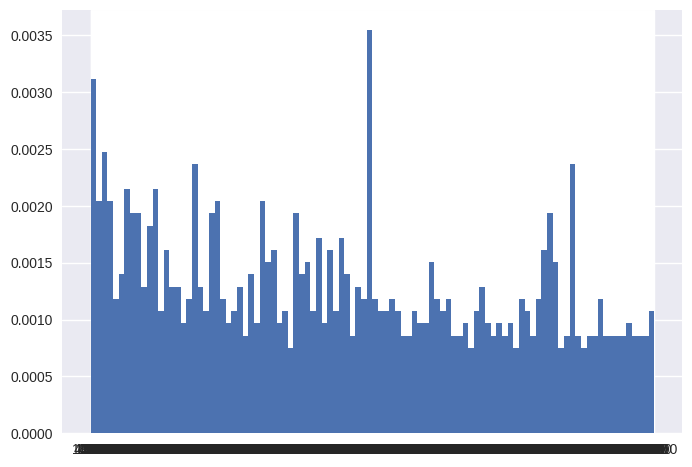

In [ ]:
# plot histogram authorMeta/digg
plt.hist(tiktok['authorMeta/digg'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

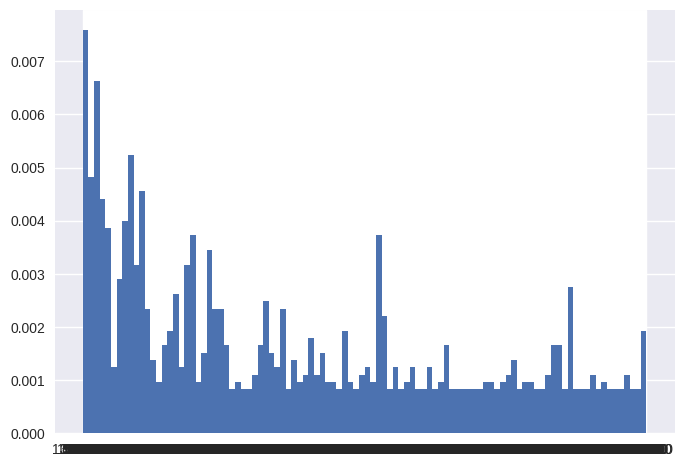

In [ ]:
# plot histogram authorMeta/fans
plt.hist(tiktok['authorMeta/fans'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

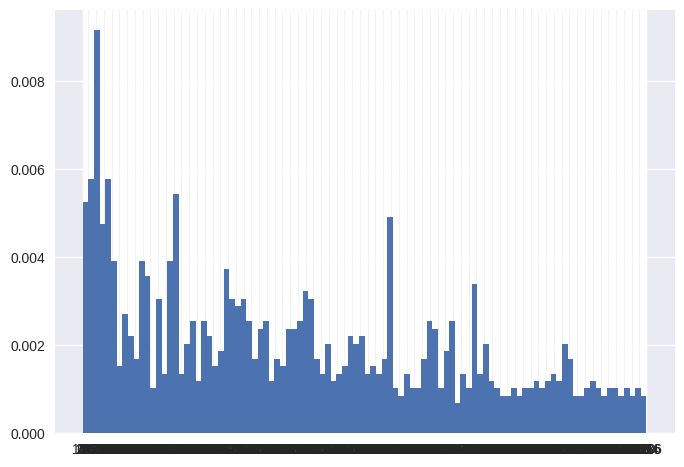

In [ ]:
# plot histogram authorMeta/following
plt.hist(tiktok['authorMeta/following'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

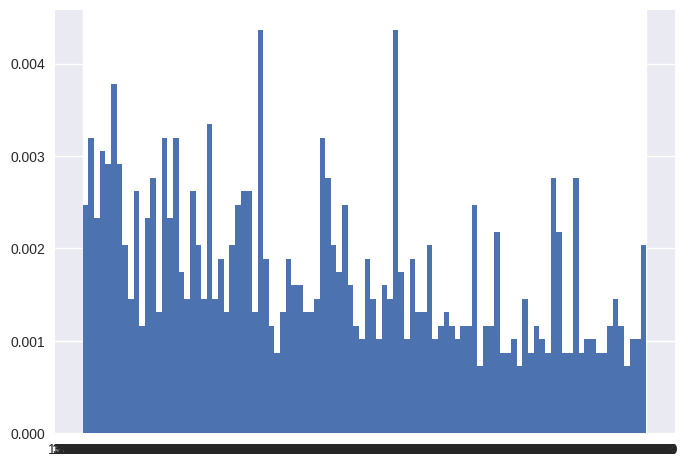

In [ ]:
# plot histogram authorMeta/heart
plt.hist(tiktok['authorMeta/heart'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

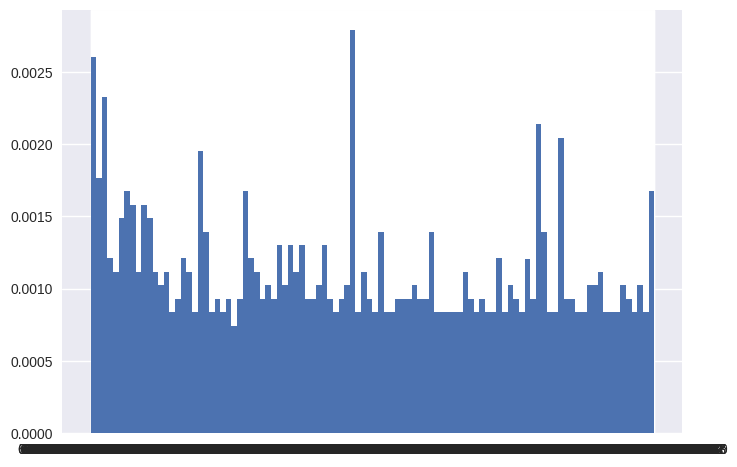

In [ ]:
# plot histogram authorMeta/id
plt.hist(tiktok['authorMeta/id'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

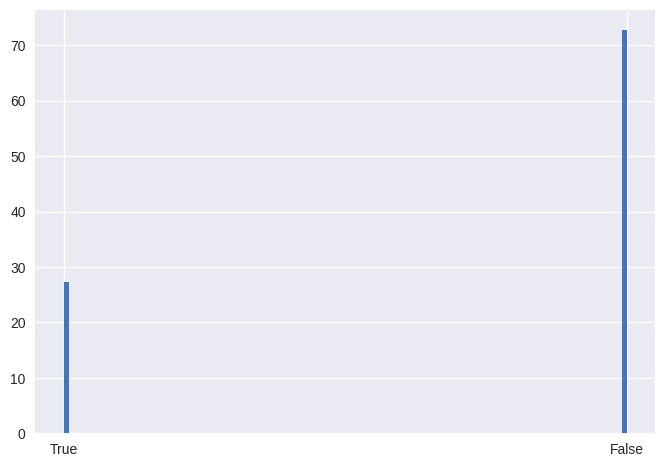

In [ ]:
# plot histogram authorMeta/verified
plt.hist(tiktok['authorMeta/verified'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

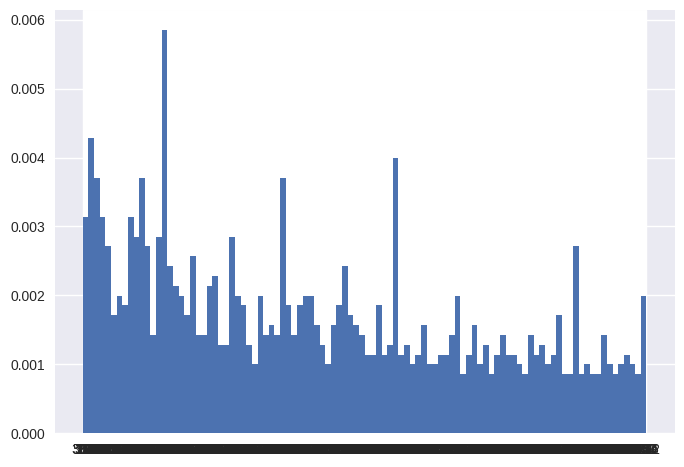

In [ ]:
# plot histogram authorMeta/video
plt.hist(tiktok['authorMeta/video'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

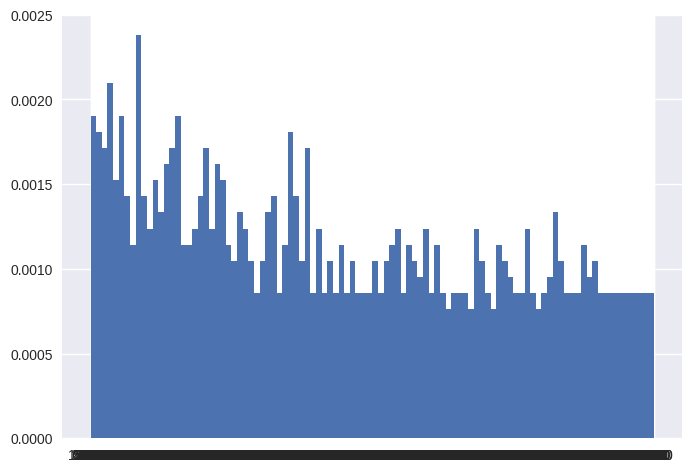

In [ ]:
# plot histogram commentCount
plt.hist(tiktok['commentCount'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

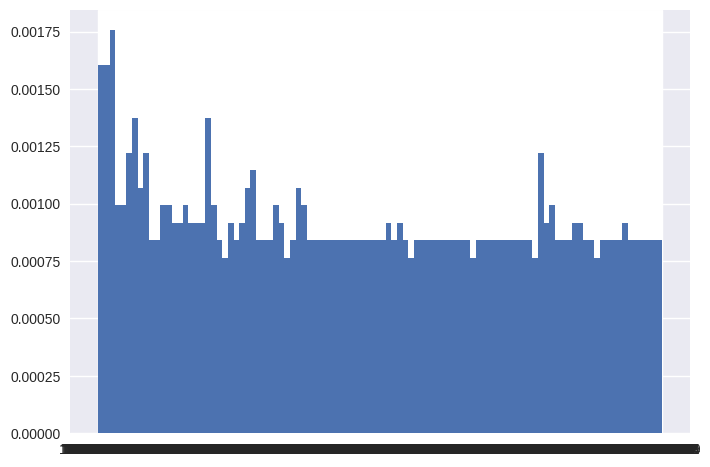

In [ ]:
# plot histogram createTime
plt.hist(tiktok['createTime'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

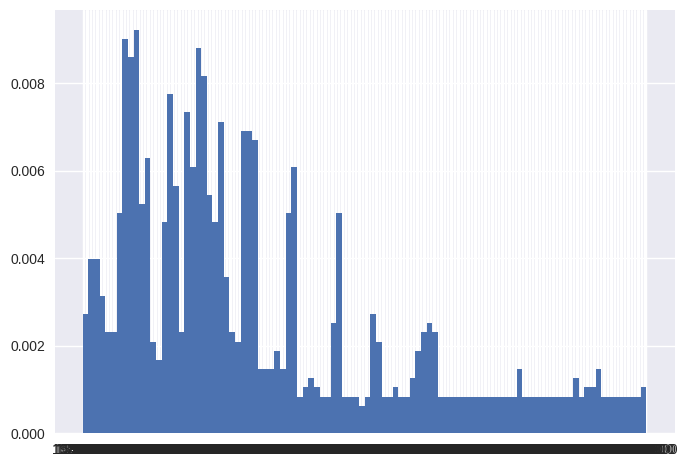

In [ ]:
# plot histogram diggCount
plt.hist(tiktok['diggCount'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

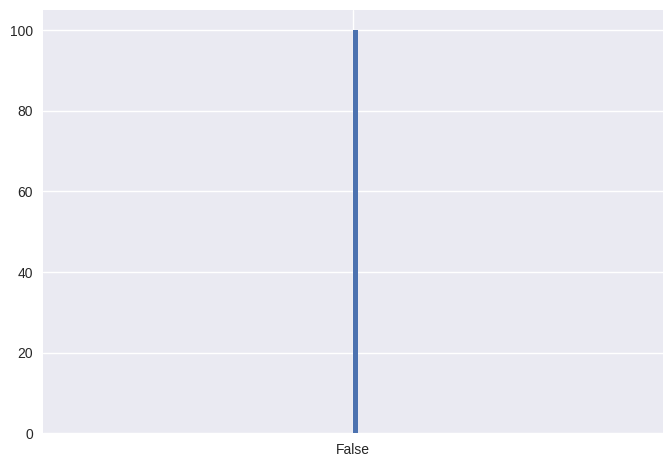

In [ ]:
# plot histogram downloaded
plt.hist(tiktok['downloaded'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

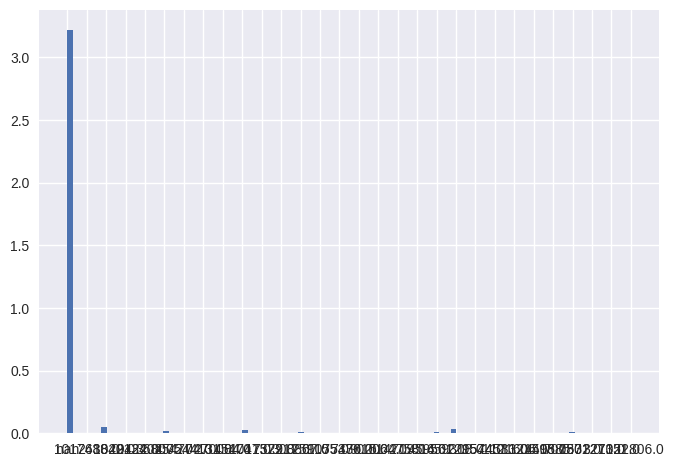

In [ ]:
# plot histogram effectStickers/0/ID
plt.hist(tiktok['effectStickers/0/ID'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

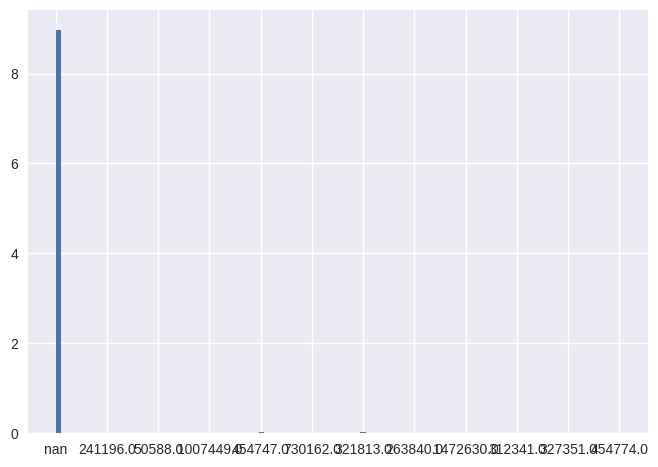

In [ ]:
# plot histogram effectStickers/1/ID
plt.hist(tiktok['effectStickers/1/ID'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

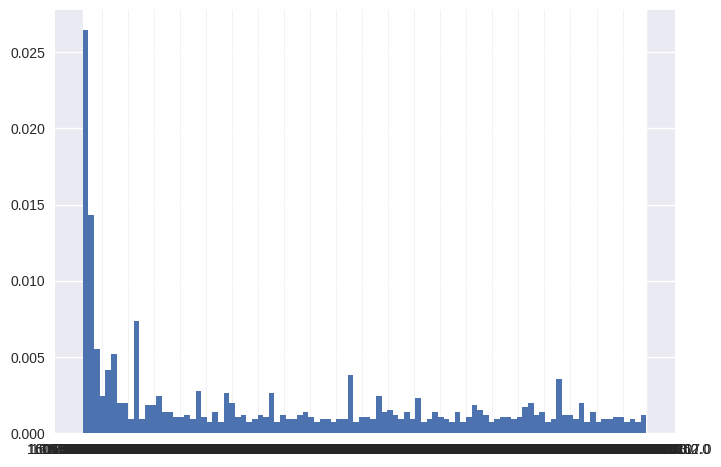

In [ ]:
# plot histogram hashtags/0/id
plt.hist(tiktok['hashtags/0/id'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

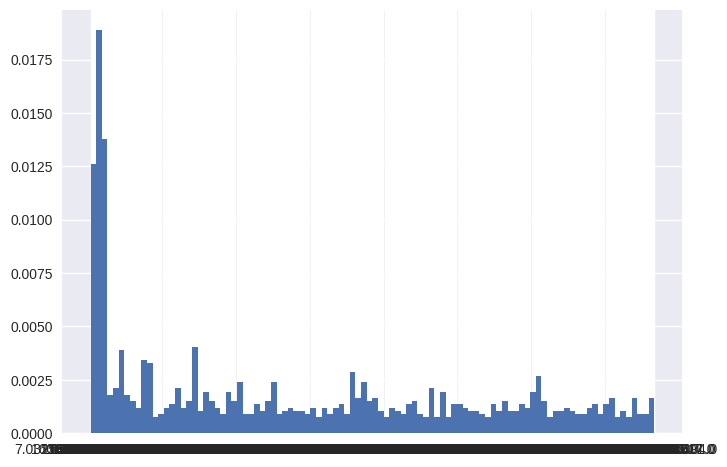

In [ ]:
# plot histogram hashtags/1/id
plt.hist(tiktok['hashtags/1/id'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

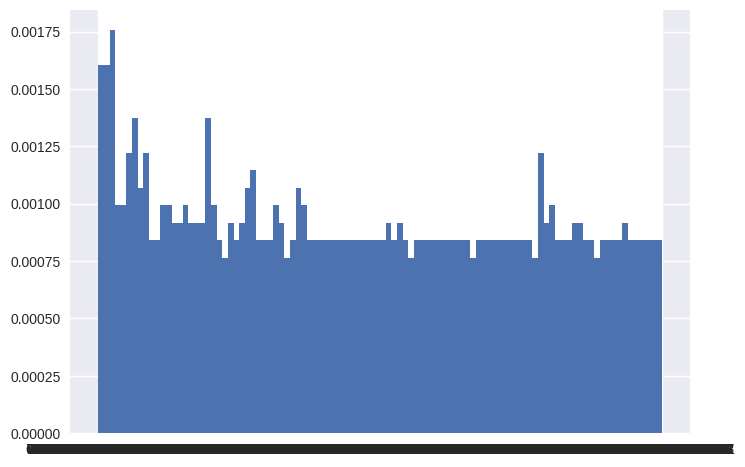

In [ ]:
# plot histogram id
plt.hist(tiktok['id'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

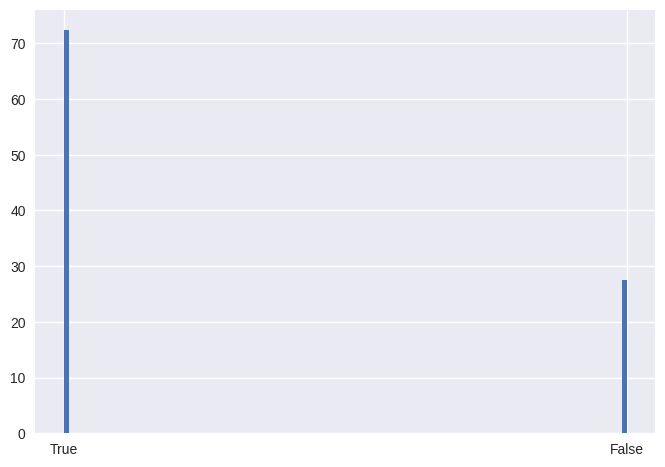

In [ ]:
# plot histogram musicMeta/musicOriginal
plt.hist(tiktok['musicMeta/musicOriginal'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

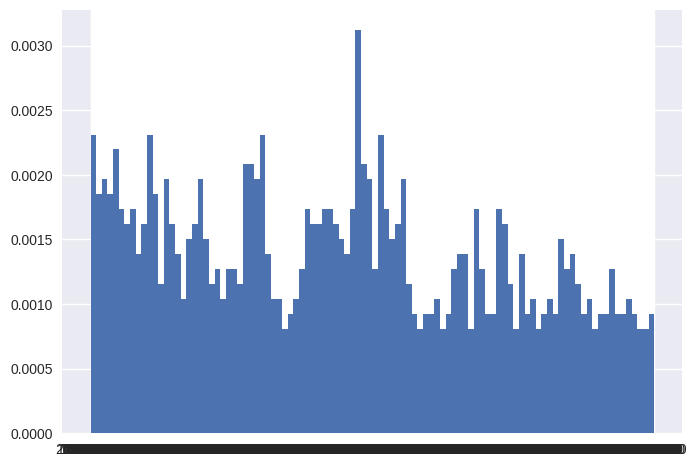

In [ ]:
# plot histogram playCount
plt.hist(tiktok['playCount'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

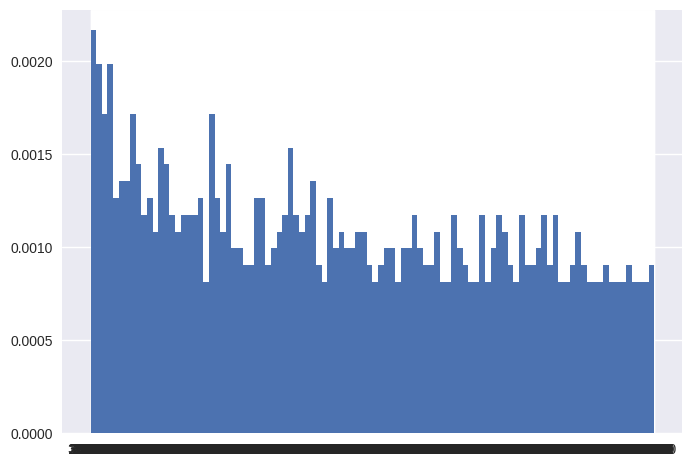

In [ ]:
# plot histogram shareCount
plt.hist(tiktok['shareCount'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

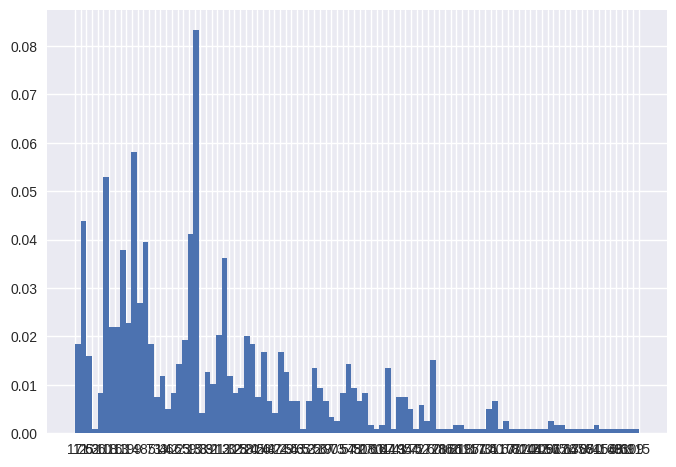

In [ ]:
# plot histogram videoMeta/duration
plt.hist(tiktok['videoMeta/duration'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

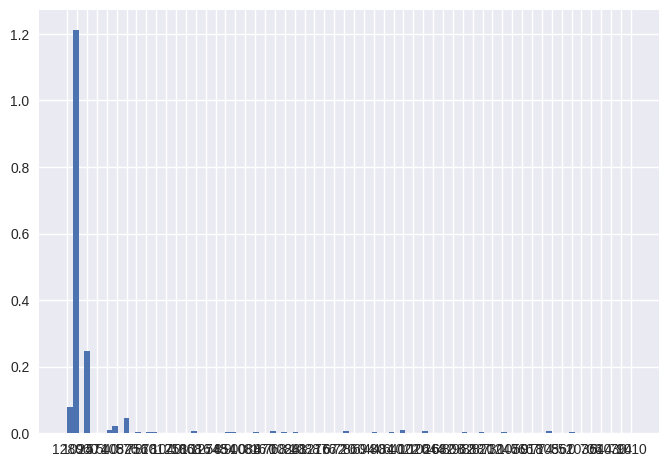

In [ ]:
# plot histogram videoMeta/height
plt.hist(tiktok['videoMeta/height'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

[]

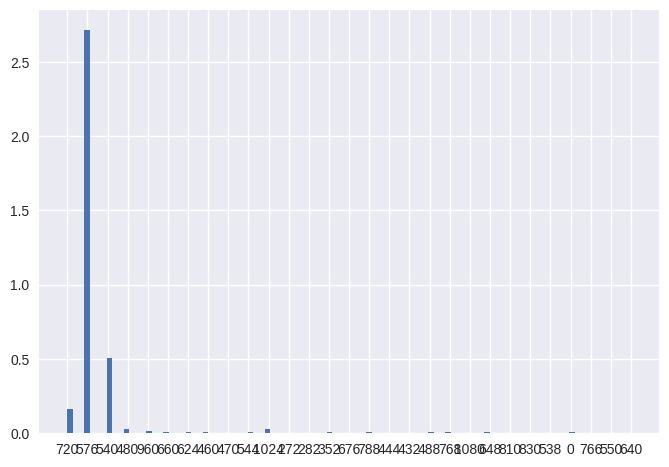

In [ ]:
# plot histogram videoMeta/width
plt.hist(tiktok['videoMeta/width'].astype(str), density=True, bins=100) # Convert the values to strings
plt.plot()

In [ ]:
# Melihat nilai numerik dengan Median
median_authorMeta_fans = tiktok['authorMeta/fans'].median()
median_playCount = tiktok['playCount'].median()
median_commentCount = tiktok['commentCount'].median()
print(f"Nilai median untuk kolom authorMeta/fans : {median_authorMeta_fans}")
print(f"Nilai median untuk kolom playCount : {median_playCount}")
print(f"Nilai median untuk kolom commentCount : {median_commentCount}")

Nilai median untuk kolom authorMeta/fans : 1300000.0
Nilai median untuk kolom playCount : 36900000.0
Nilai median untuk kolom commentCount : 29500.0


In [ ]:
# Melihat nilai numerik dengan Sum
sum_diggCount = tiktok['diggCount'].sum()
sum_shareCount = tiktok['shareCount'].sum()
sum_videoMeta_duration = tiktok['videoMeta/duration'].sum()
print(f"Nilai sum untuk kolom diggCount : {sum_diggCount}")
print(f"Nilai sum untuk kolom shareCount : {sum_shareCount}")
print(f"Nilai sum untuk kolom videoMeta/duration : {sum_videoMeta_duration}")

Nilai sum untuk kolom diggCount : 7893273979
Nilai sum untuk kolom shareCount : 188359200
Nilai sum untuk kolom videoMeta/duration : 35690


In [ ]:
# Melihat nilai kategorikal dengan Mode
mode_authorMeta_avatar = tiktok['authorMeta/avatar'].mode()[0]
mode_authorMeta_name = tiktok['authorMeta/name'].mode()[0]
mode_authorMeta_nickName = tiktok['authorMeta/nickName'].mode()[0]
mode_authorMeta_signature = tiktok['authorMeta/signature'].mode()[0]
mode_musicMeta_musicAlbum = tiktok['musicMeta/musicAlbum'].mode()[0]
mode_musicMeta_musicAuthor = tiktok['musicMeta/musicAuthor'].mode()[0]
mode_musicMeta_musicName = tiktok['musicMeta/musicName'].mode()[0]
mode_musicMeta_playUrl = tiktok['musicMeta/playUrl'].mode()[0]
mode_searchHashtag_name = tiktok['searchHashtag/name'].mode()[0]
mode_searchHashtag_views = tiktok['searchHashtag/views'].mode()[0]
print(f"Nilai mode untuk kolom authorMeta/avatar : {mode_authorMeta_avatar}")
print(f"Nilai mode untuk kolom authorMeta/name : {mode_authorMeta_name}")
print(f"Nilai mode untuk kolom authorMeta/nickName : {mode_authorMeta_nickName}")
print(f"Nilai mode untuk kolom authorMeta/authorMeta/signature : {mode_authorMeta_signature}")
print(f"Nilai mode untuk kolom musicMeta/musicAlbum : {mode_musicMeta_musicAlbum}")
print(f"Nilai mode untuk kolom musicMeta/musicAuthor : {mode_musicMeta_musicAuthor}")
print(f"Nilai mode untuk kolom musicMeta/musicName : {mode_musicMeta_musicName}")
print(f"Nilai mode untuk kolom musicMeta/playUrl : {mode_musicMeta_playUrl}")
print(f"Nilai mode untuk kolom searchHashtag/name : {mode_searchHashtag_name}")
print(f"Nilai mode untuk kolom searchHashtag/views : {mode_searchHashtag_views}")

Nilai mode untuk kolom authorMeta/avatar : https://p16-sign-va.tiktokcdn.com/tos-maliva-avt-0068/0465f8ceeb872bb03f30fb7ecc099a5a~c5_720x720.jpeg?x-expires=1659128400&x-signature=QvxRNu%2BS5O2oUHx8zY7lSMbYM2M%3D
Nilai mode untuk kolom authorMeta/name : khaby.lame
Nilai mode untuk kolom authorMeta/nickName : Khabane lame
Nilai mode untuk kolom authorMeta/authorMeta/signature : Se vuoi ridere sei nel posto giusto 
If u wanna laugh u r in the right place
Nilai mode untuk kolom musicMeta/musicAlbum : Monkeys Spinning Monkeys
Nilai mode untuk kolom musicMeta/musicAuthor : Khabane lame
Nilai mode untuk kolom musicMeta/musicName : original sound
Nilai mode untuk kolom musicMeta/playUrl : https://sf16-ies-music-va.tiktokcdn.com/obj/musically-maliva-obj/6882822775841770246.mp3
Nilai mode untuk kolom searchHashtag/name : 5minworkout
Nilai mode untuk kolom searchHashtag/views : 3.6B


In [ ]:
# Melihat nilai kategorikal dengan Mean
mean_authorMeta_fans = tiktok['authorMeta/fans'].mean()
mean_playCount = tiktok['playCount'].mean()
mean_videoMeta_duration = tiktok['videoMeta/duration'].mean()
print(f"Nilai mean untuk kolom authorMeta/fans : {mean_authorMeta_fans}")
print(f"Nilai mean untuk kolom playCount : {mean_playCount}")
print(f"Nilai mean untuk kolom videoMeta/duration : {mean_videoMeta_duration}")

Nilai mean untuk kolom authorMeta/fans : 7124048.6375
Nilai mean untuk kolom playCount : 54687184.89083333
Nilai mean untuk kolom videoMeta/duration : 29.741666666666667


Disini aku mau klarifikasi terlebih dahulu, aku memutuskan untuk tidak melakukan missing value, kenapa? karena dari 51 kolom itu jumlah isinya jauh berbeda, kecuali dari 24 kolom hanya kurang 3 atau 5 isi saja bisa dilakukan dengan imputasi missing value.

# Pengecekan Outlier Menggunakan Box Plot

<Axes: >

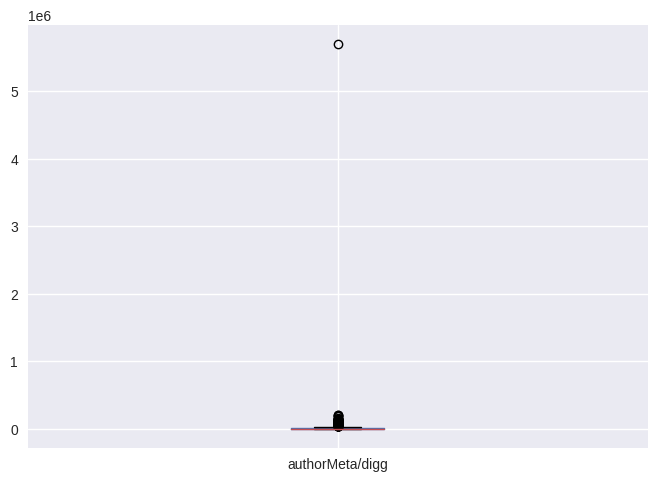

In [ ]:
tiktok[['authorMeta/digg']].boxplot()

<Axes: >

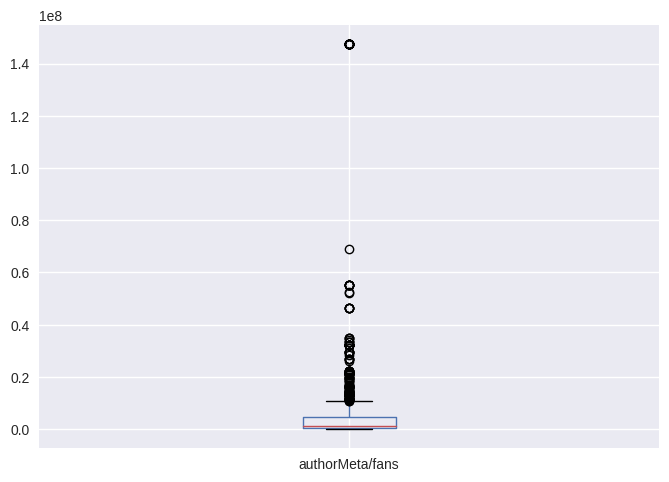

In [ ]:
tiktok[['authorMeta/fans']].boxplot()

<Axes: >

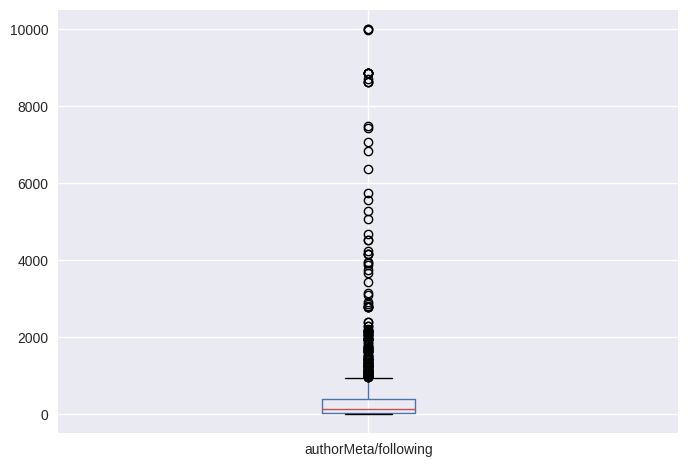

In [ ]:
tiktok[['authorMeta/following']].boxplot()

<Axes: >

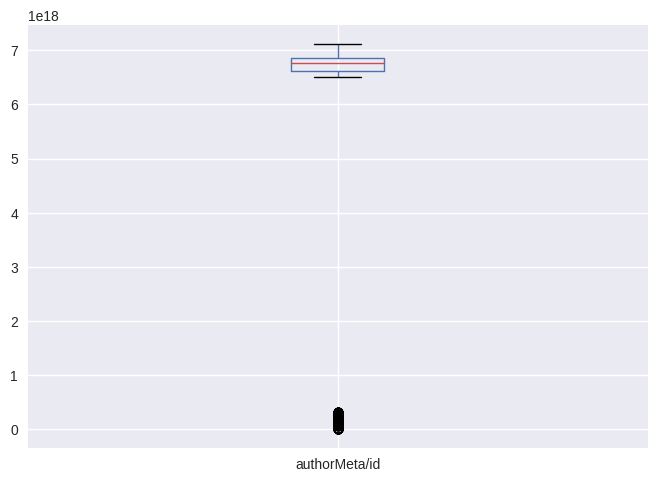

In [ ]:
tiktok[['authorMeta/id']].boxplot()

<Axes: >

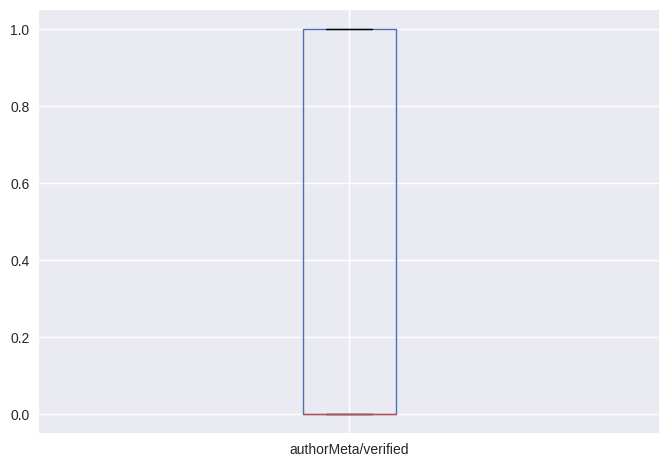

In [ ]:
tiktok[['authorMeta/verified']].boxplot()

<Axes: >

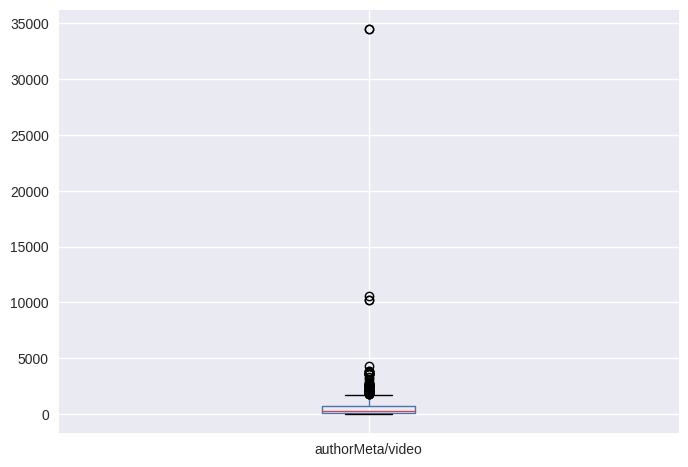

In [ ]:
tiktok[['authorMeta/video']].boxplot()

<Axes: >

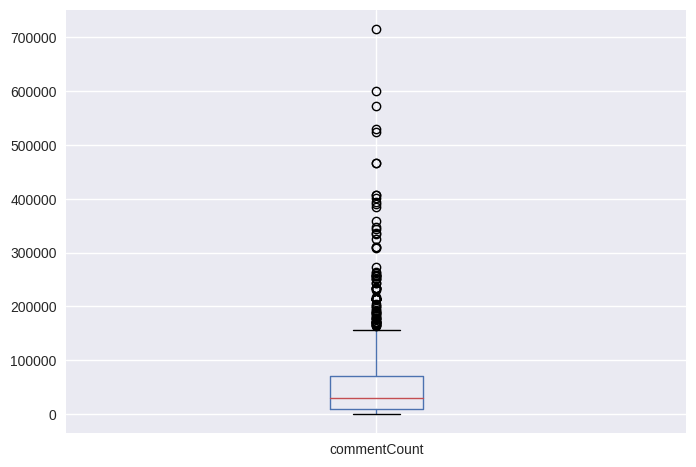

In [ ]:
tiktok[['commentCount']].boxplot()

<Axes: >

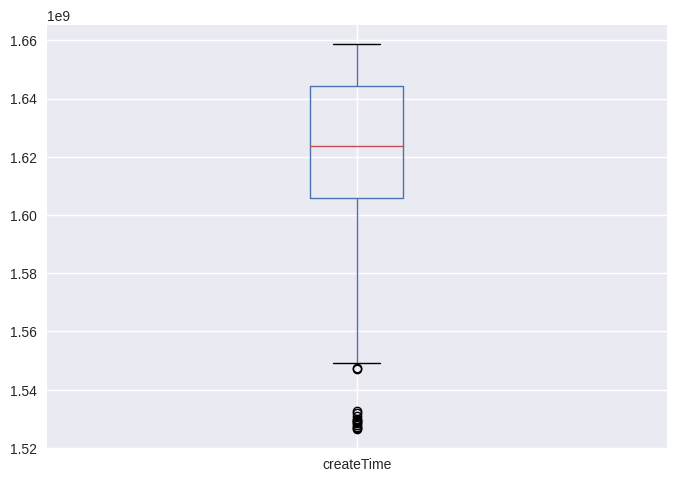

In [ ]:
tiktok[['createTime']].boxplot()

<Axes: >

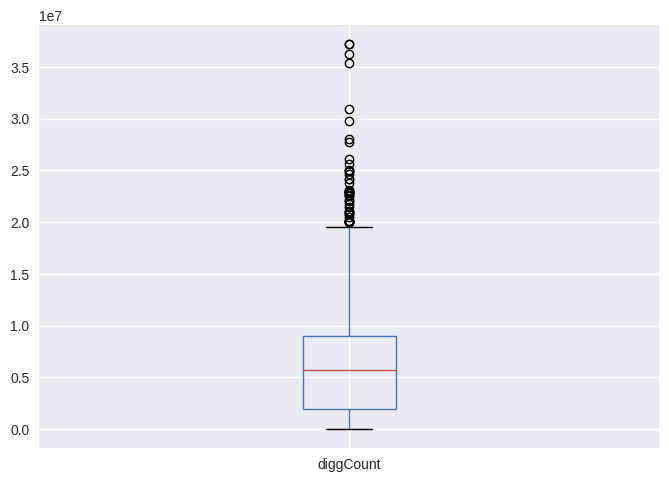

In [ ]:
tiktok[['diggCount']].boxplot()

<Axes: >

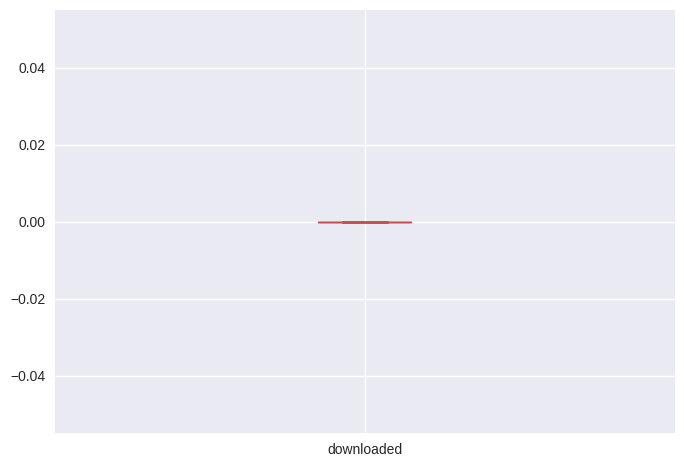

In [ ]:
tiktok[['downloaded']].boxplot()

<Axes: >

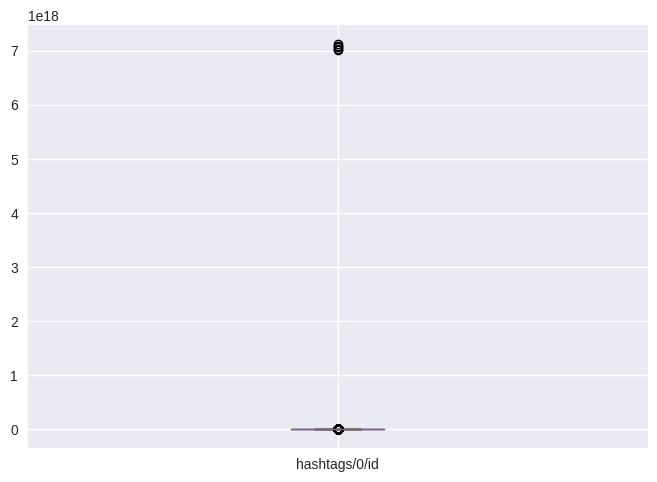

In [ ]:
tiktok[['hashtags/0/id']].boxplot()

<Axes: >

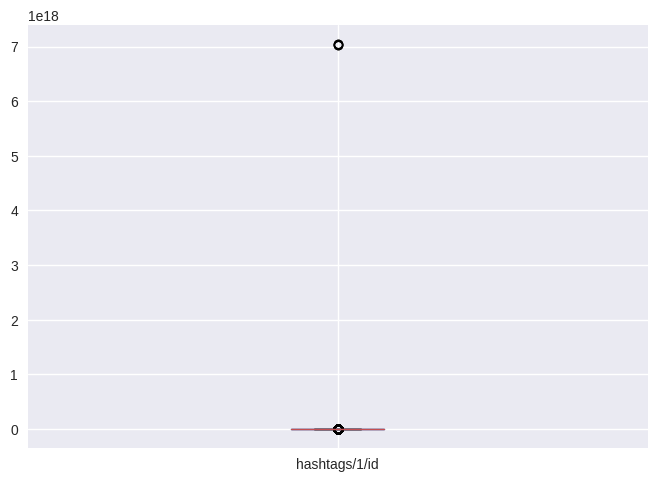

In [ ]:
tiktok[['hashtags/1/id']].boxplot()

<Axes: >

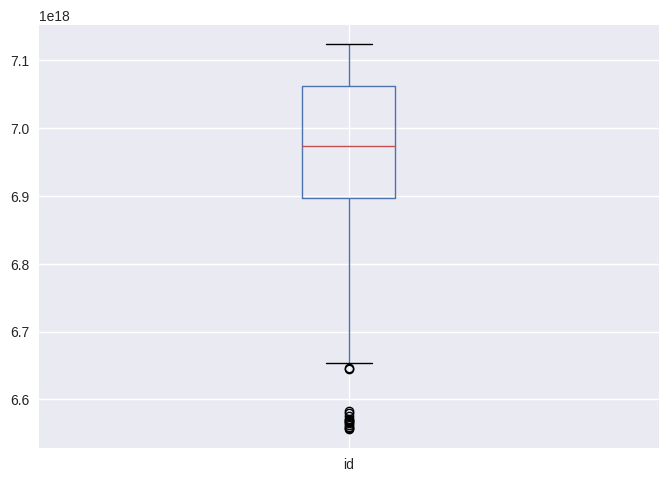

In [ ]:
tiktok[['id']].boxplot()

<Axes: >

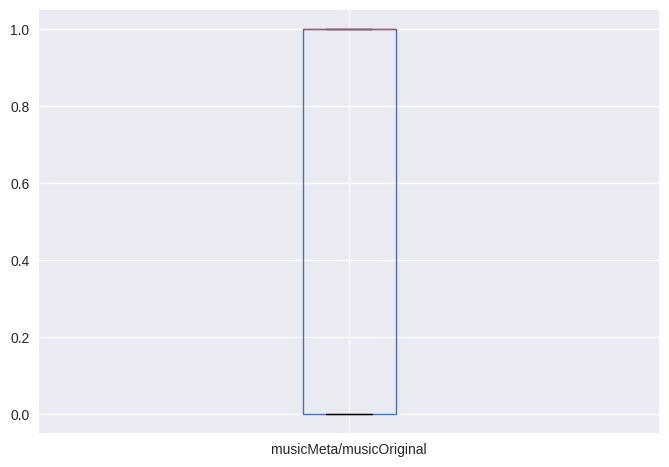

In [ ]:
tiktok[['musicMeta/musicOriginal']].boxplot()

<Axes: >

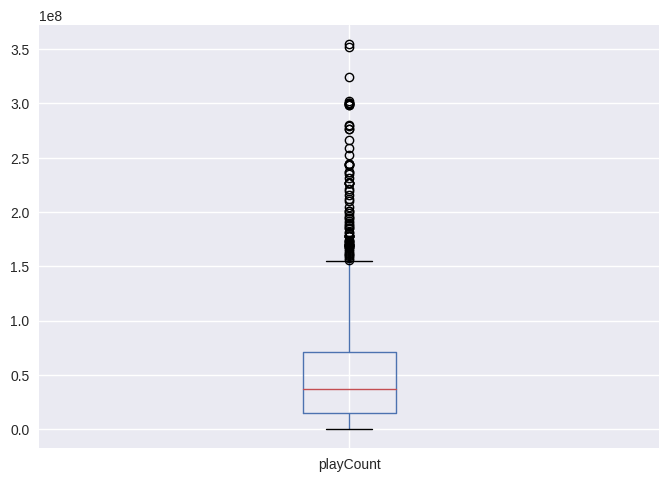

In [ ]:
tiktok[['playCount']].boxplot()

<Axes: >

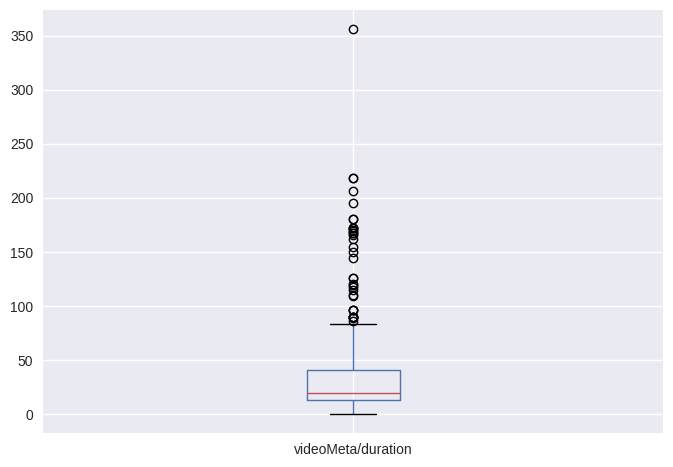

In [ ]:
tiktok[['videoMeta/duration']].boxplot()

<Axes: >

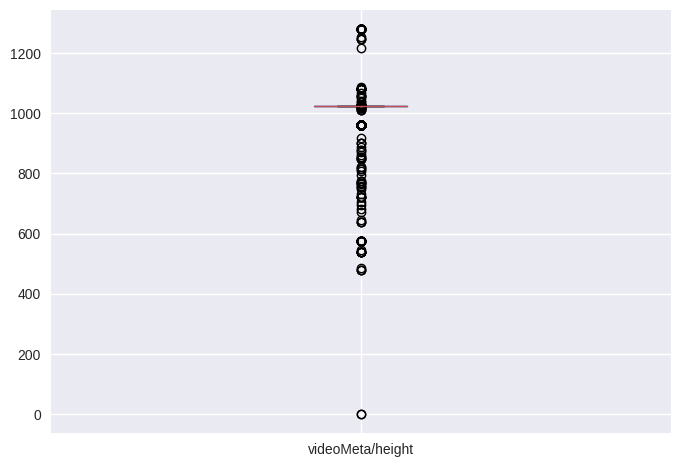

In [ ]:
tiktok[['videoMeta/height']].boxplot()

<Axes: >

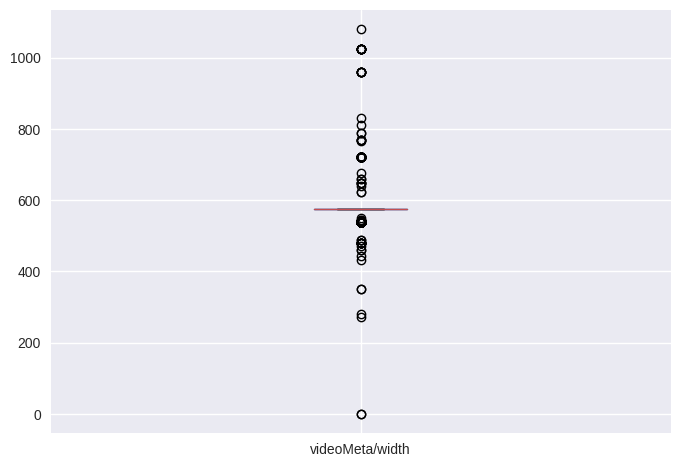

In [ ]:
tiktok[['videoMeta/width']].boxplot()

Tindak lanjuti outlier diatas

In [ ]:
  List=['authorMeta/digg','authorMeta/fans', 'authorMeta/following', 'authorMeta/verified',
       'authorMeta/video', 'commentCount', 'createTime', 'diggCount', 'id', 'playCount',
       'videoMeta/duration', 'videoMeta/height', 'videoMeta/width']

for col in List:

    if tiktok[col].dtype == bool:

      print(f"Skipping boolean column: {col}")
      continue


    q1 = np.percentile(tiktok[col], 25)
    q3 = np.percentile(tiktok[col], 75)

    # Calculate IQR
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    filtered_tiktok = tiktok[tiktok[col] >= lower_bound]
    filtered_tiktok = filtered_tiktok[filtered_tiktok[col] <= upper_bound]

    tiktok = filtered_tiktok.copy()

Skipping boolean column: authorMeta/verified


<Axes: >

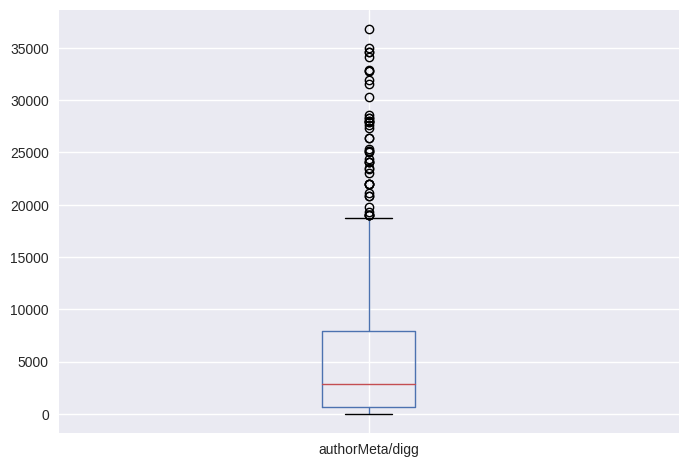

In [ ]:
tiktok[['authorMeta/digg']].boxplot()

<Axes: >

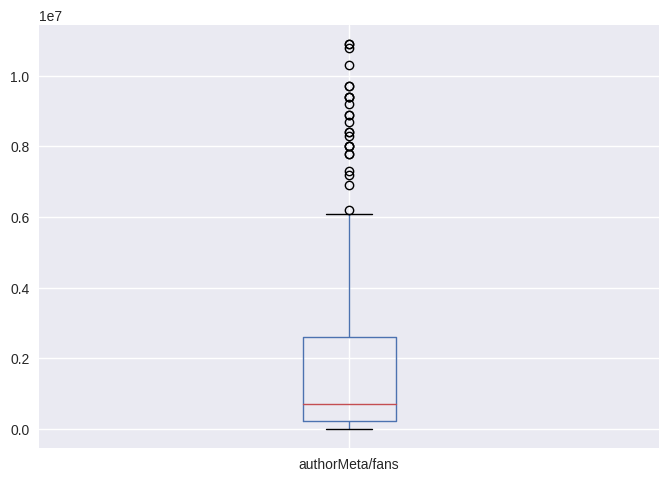

In [ ]:
tiktok[['authorMeta/fans']].boxplot()

<Axes: >

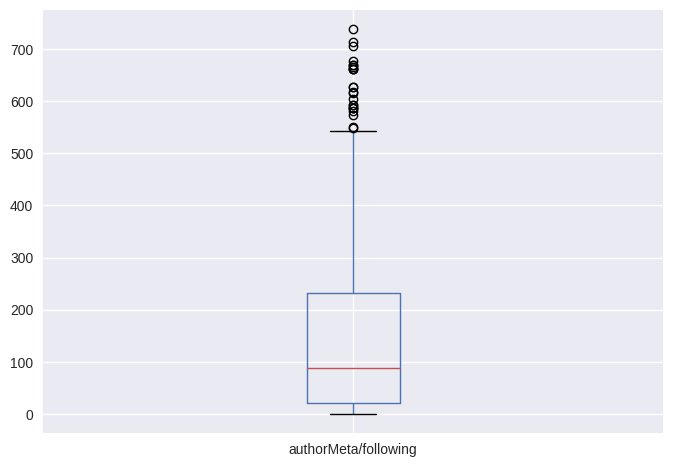

In [ ]:
tiktok[['authorMeta/following']].boxplot()

<Axes: >

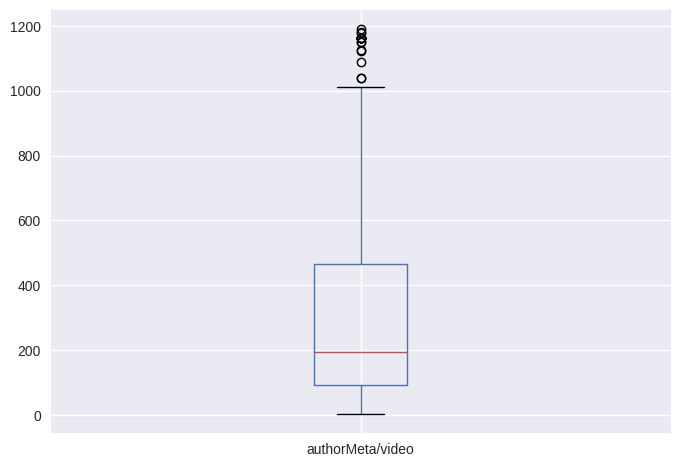

In [ ]:
tiktok[['authorMeta/video']].boxplot()

<Axes: >

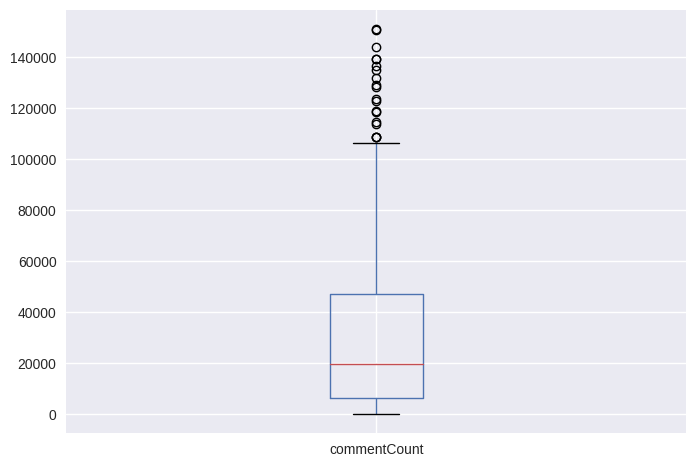

In [ ]:
tiktok[['commentCount']].boxplot()

<Axes: >

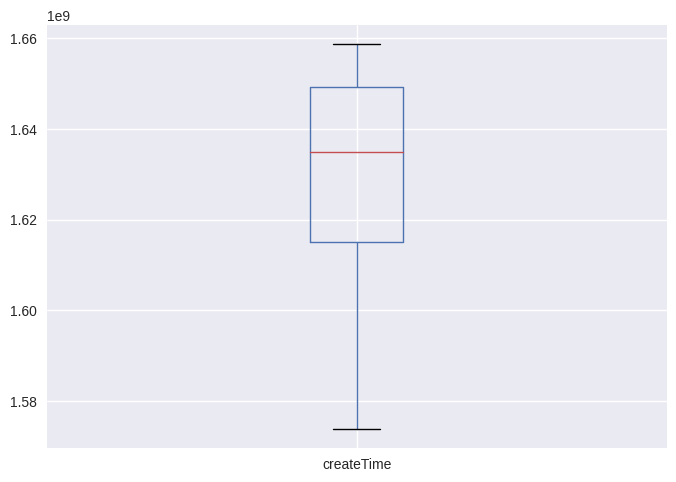

In [ ]:
tiktok[['createTime']].boxplot()

<Axes: >

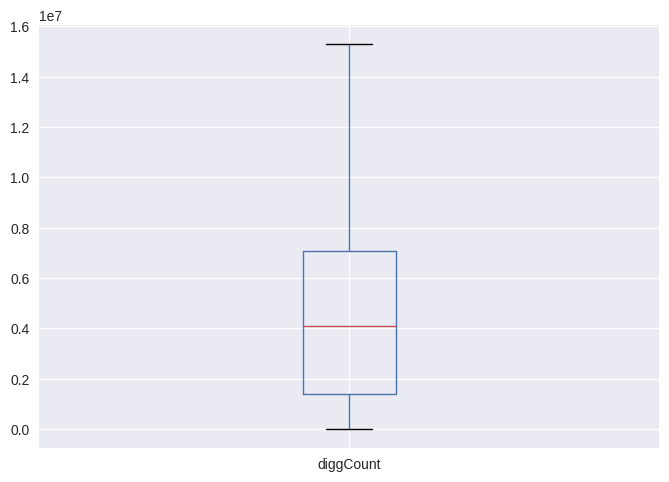

In [ ]:
tiktok[['diggCount']].boxplot()

<Axes: >

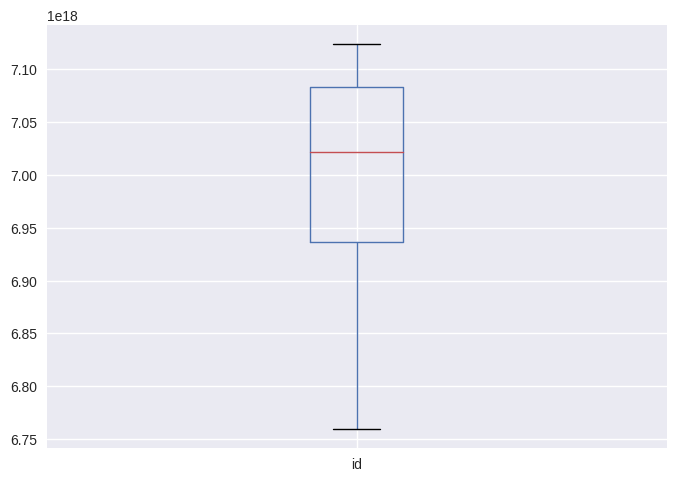

In [ ]:
tiktok[['id']].boxplot()

<Axes: >

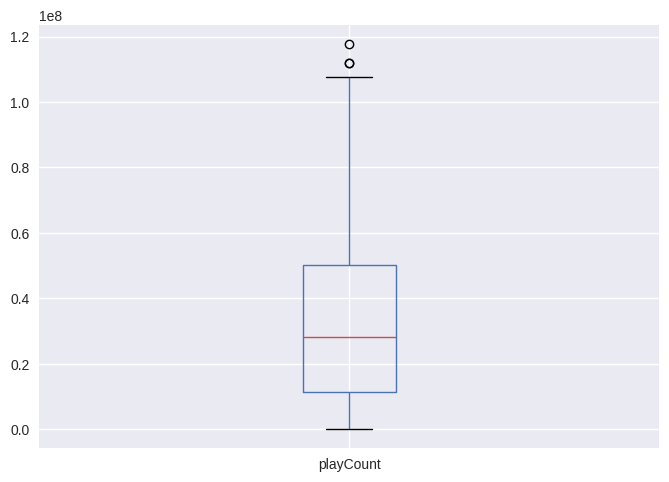

In [ ]:
tiktok[['playCount']].boxplot()

<Axes: >

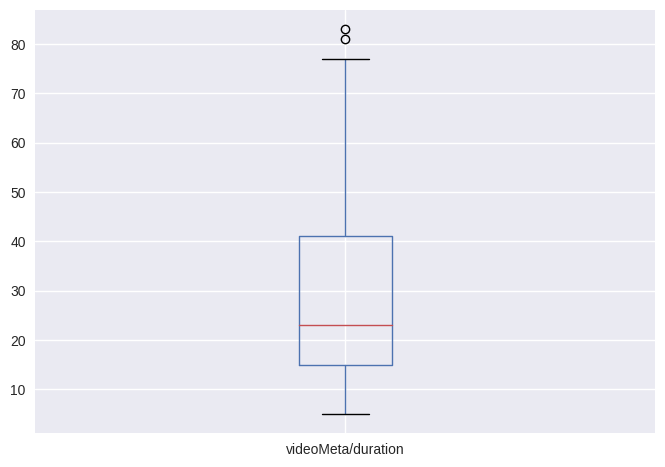

In [ ]:
tiktok[['videoMeta/duration']].boxplot()

<Axes: >

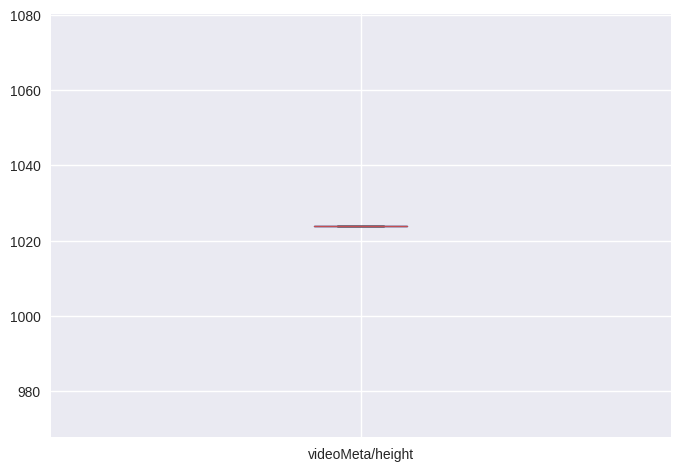

In [ ]:
tiktok[['videoMeta/height']].boxplot()

<Axes: >

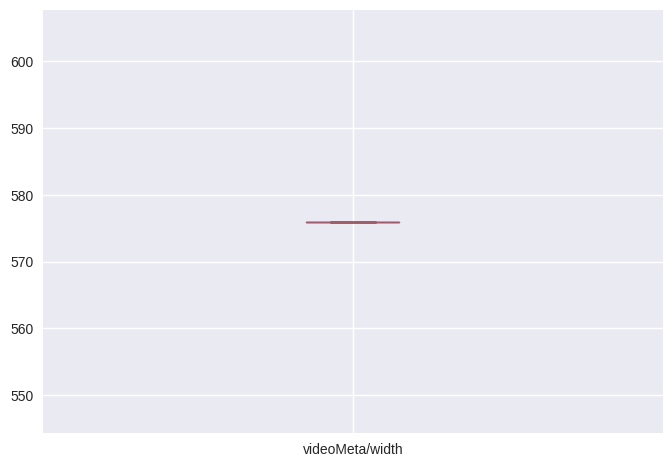

In [ ]:
tiktok[['videoMeta/width']].boxplot()

# Label Encoding

In [ ]:
tiktok.info()

<class 'pandas.core.frame.DataFrame'>
Index: 430 entries, 2 to 1199
Data columns (total 52 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   authorMeta/avatar                       430 non-null    object 
 1   authorMeta/digg                         430 non-null    int64  
 2   authorMeta/fans                         430 non-null    int64  
 3   authorMeta/following                    430 non-null    int64  
 4   authorMeta/heart                        430 non-null    int64  
 5   authorMeta/id                           430 non-null    int64  
 6   authorMeta/name                         430 non-null    object 
 7   authorMeta/nickName                     420 non-null    object 
 8   authorMeta/signature                    397 non-null    object 
 9   authorMeta/verified                     430 non-null    bool   
 10  authorMeta/video                        430 non-null    int64  
 1

In [ ]:
# Pilih kolom numerik untuk analisis korelasi
numerical_columns = tiktok.select_dtypes(include=['int8', 'int64']).columns
numerical_data = tiktok[numerical_columns]

# Hitung matriks korelasi
correlation_matrix = numerical_data.corr()

# Korelasi variabel 'actual_time' dengan variabel lainnya
correlation_with_authorMeta_id = correlation_matrix['authorMeta/id'].sort_values(ascending=False)
print(correlation_with_authorMeta_id)

authorMeta/id           1.000000
diggCount               0.088042
commentCount            0.042058
playCount               0.022726
authorMeta/following    0.011833
videoMeta/duration      0.007982
shareCount             -0.006393
authorMeta/digg        -0.067946
createTime             -0.083536
id                     -0.083545
authorMeta/heart       -0.138122
authorMeta/fans        -0.138676
authorMeta/video       -0.272362
videoMeta/height             NaN
videoMeta/width              NaN
Name: authorMeta/id, dtype: float64


In [ ]:
# Hapus Saja Kolom videoMeta/height dan videoMeta/width
tiktok = tiktok.drop(['videoMeta/height', 'videoMeta/width'], axis=1)

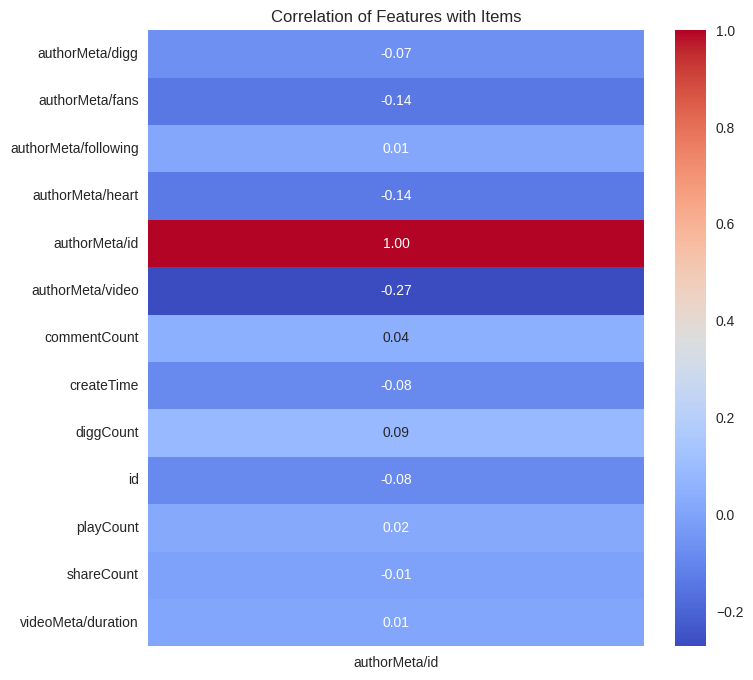

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix[['authorMeta/id']], annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation of Features with Items')
plt.show()

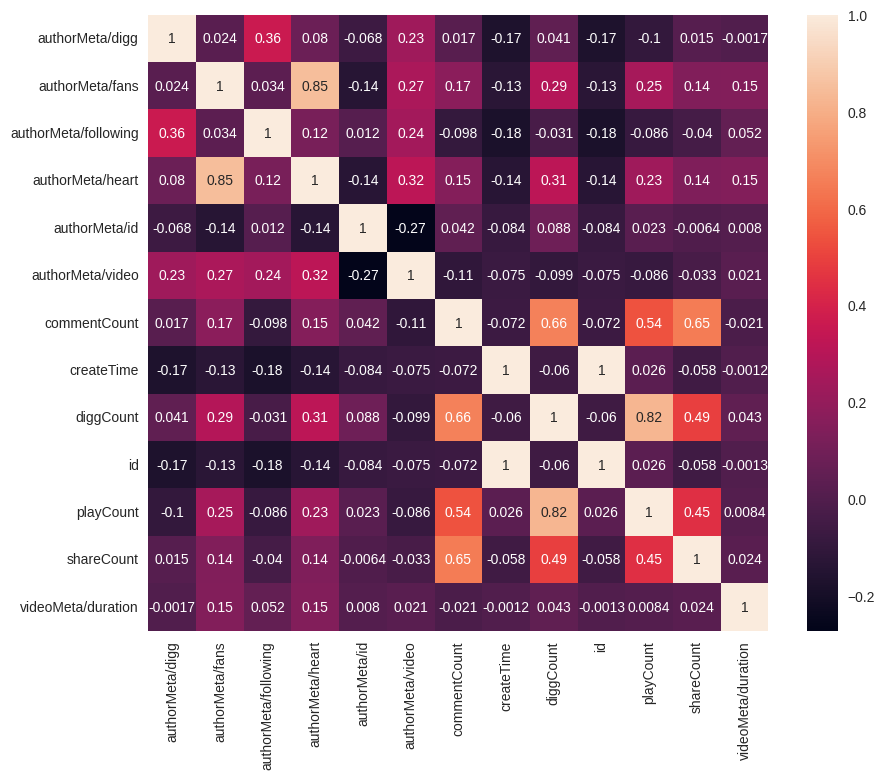

In [ ]:
numeric_cols = tiktok.select_dtypes(include=['int64']).columns
correlation_matrix = tiktok[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

# Linear Regression

In [ ]:
tiktok.columns

Index(['authorMeta/avatar', 'authorMeta/digg', 'authorMeta/fans',
       'authorMeta/following', 'authorMeta/heart', 'authorMeta/id',
       'authorMeta/name', 'authorMeta/nickName', 'authorMeta/signature',
       'authorMeta/verified', 'authorMeta/video', 'commentCount', 'createTime',
       'createTimeISO', 'diggCount', 'downloaded', 'effectStickers/0/ID',
       'effectStickers/0/name', 'effectStickers/0/stickerStats/useCount',
       'effectStickers/1/ID', 'effectStickers/1/name',
       'effectStickers/1/stickerStats/useCount', 'hashtags/0/cover',
       'hashtags/0/id', 'hashtags/0/name', 'hashtags/0/title',
       'hashtags/1/cover', 'hashtags/1/id', 'hashtags/1/name',
       'hashtags/1/title', 'id', 'mediaUrls/0', 'mentions/0', 'mentions/1',
       'mentions/2', 'mentions/3', 'mentions/4', 'mentions/5',
       'musicMeta/musicAlbum', 'musicMeta/musicAuthor', 'musicMeta/musicName',
       'musicMeta/musicOriginal', 'musicMeta/playUrl', 'playCount',
       'searchHashtag/name', 

In [ ]:
y = tiktok['shareCount']
X = tiktok['authorMeta/digg']
X = tiktok['authorMeta/fans']
X = tiktok['commentCount']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=2529)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((301,), (129,), (301,), (129,))

In [ ]:
model = LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1),y_train)

LinearRegression()

In [ ]:
print(f"Koefisien: {model.coef_}")
print(f"Intersep: {model.intercept_}")

Koefisien: [2.52040817]
Intersep: 8134.791419382775


In [ ]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

In [ ]:
y_pred

array([193888.87375651, 139700.09804079, 213548.05750453, 216824.58812921,
       133903.1592433 ,  11920.44449496,  16258.06696039,  13684.73021594,
       294705.20066947,  32403.8017155 , 126593.97554211,  16749.5465541 ,
        18218.94451885,  97609.28155463,  19711.02615716,  13387.32205155,
       388968.46633308,  17266.23022952,  17404.85267903,  59803.15896227,
       115756.22039897,  25792.77107819,  66104.17939433,  68120.50593259,
        22400.30167757, 206490.91462063,  39135.81194512,  87779.68968062,
       351918.46619257, 145497.03683829, 331251.11917541,  32005.5772242 ,
       147513.36337655,  13634.32205248, 340324.58859758,  28509.77108849,
        26319.53638631, 102398.057083  ,  23380.74045679, 266980.7107684 ,
        79714.38352758,  89039.89376703,  13112.59756071, 178514.38390228,
        61063.36304869, 165156.22058631,  89796.01621888,  56022.54670304,
        13324.31184723, 359731.73152832,  39639.89357968,  92316.4243917 ,
        37875.60785871,  

In [ ]:
mean_absolute_error(y_test,y_pred)
mean_absolute_percentage_error(y_test,y_pred)
mean_squared_error(y_test,y_pred)

15596180659.767635

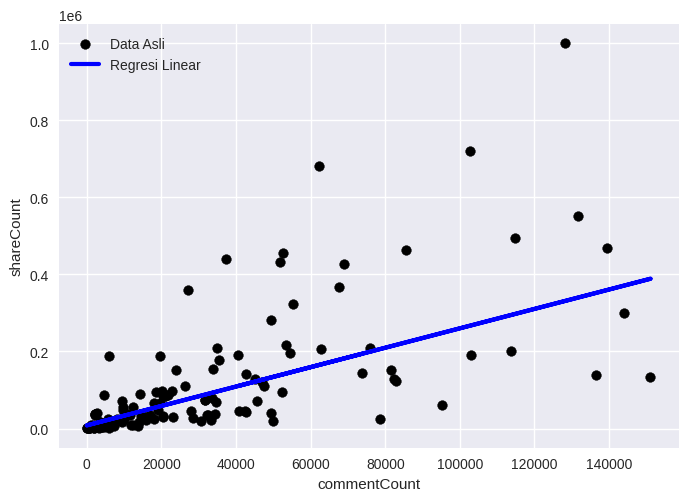

In [ ]:
plt.scatter(X_test, y_test, color='black', label='Data Asli')
plt.plot(X_test, y_pred, color='blue', linewidth=3, label='Regresi Linear')
plt.xlabel('authorMeta/digg')
plt.xlabel('authorMeta/fans')
plt.xlabel('commentCount')
plt.ylabel('shareCount')
plt.legend()
plt.show()

# Clustering With K-Means

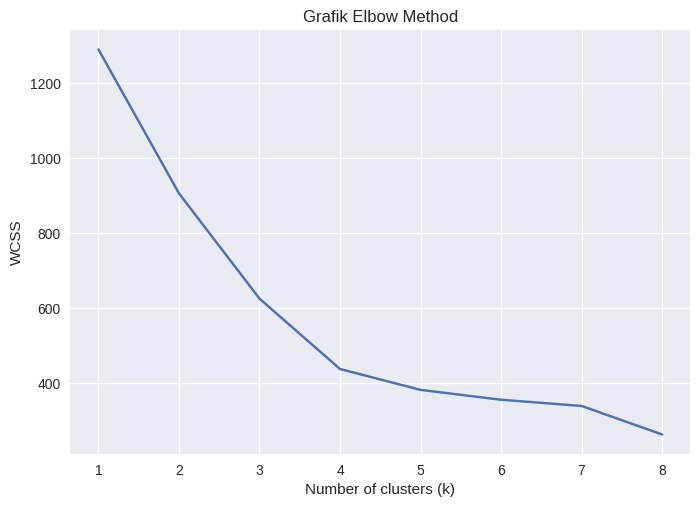

In [ ]:
numerical_columns = ['authorMeta/digg', 'authorMeta/heart', 'diggCount']
amazon_numerical = tiktok[numerical_columns]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(amazon_numerical)

wcss_list = []

for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss_list.append(kmeans.inertia_)

mtp.plot(range(1, 9), wcss_list)
mtp.title('Grafik Elbow Method')
mtp.xlabel('Number of clusters (k)')
mtp.ylabel('WCSS')
mtp.show()

# Klasifikasi

Tujuan dari Machine Learning Klasifikasi adalah untuk Memprediksi kategori tertentu berdasarkan fitur yang ada.

Contoh: Memprediksi apakah sebuah video akan menjadi viral atau tidak berdasarkan fitur seperti diggCount, commentCount, shareCount, dan lainnya.



In [ ]:
# Memilih fitur untuk clustering
X = tiktok[['authorMeta/fans', 'authorMeta/digg', 'commentCount']]

In [ ]:
# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 3. Membangun model clustering
# Menentukan jumlah cluster (k)
k = 3  # Misalkan kita ingin 3 cluster
kmeans = KMeans(n_clusters=k, random_state=42)

In [ ]:
# 4. Melatih model
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [ ]:
# 5. Membuat prediksi
clusters = kmeans.predict(X_scaled)


In [ ]:
# Menambahkan hasil cluster ke DataFrame
tiktok['Cluster'] = clusters

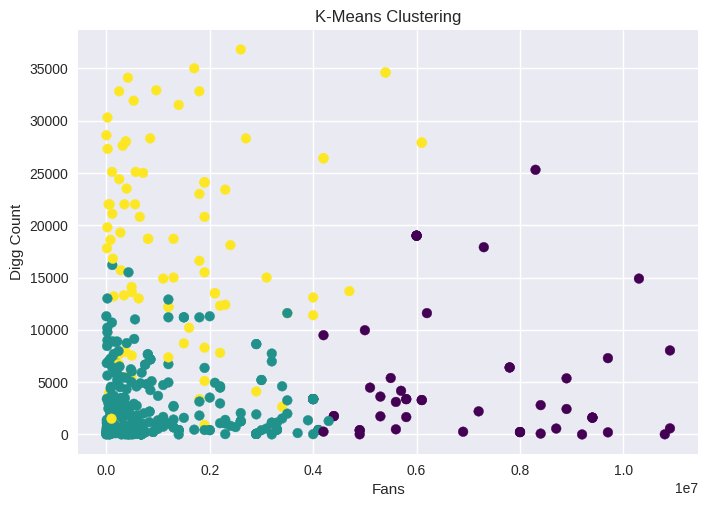

In [ ]:
# Visualisasi hasil clustering
plt.scatter(X['authorMeta/fans'], X['authorMeta/digg'], c=clusters, cmap='viridis')
plt.xlabel('Fans')
plt.ylabel('Digg Count')
plt.title('K-Means Clustering')
plt.show()

# Klasifikasi Popularitas Penulis

Tujuan: Mengklasifikasikan penulis sebagai "populer" atau "tidak populer" berdasarkan interaksi video dan jumlah pengikutnya.

In [ ]:
# Tentukan ambang batas popularitas (misalnya, penggemar > 1000 adalah yang populer)
tiktok['is_popular'] = tiktok['authorMeta/fans'].apply(lambda x: 1 if x > 1000 else 0)

In [ ]:
# Pilih Fitur- fiturnya
features = ['authorMeta/digg', 'authorMeta/fans', 'authorMeta/following',
            'authorMeta/heart', 'authorMeta/video', 'commentCount',
            'diggCount', 'playCount', 'shareCount']

In [ ]:
# Variabel independen (fitur)
X = tiktok[features]

In [ ]:
# Variabel terikat (label)
y = tiktok['is_popular']

In [ ]:
# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standarisasi fitur fiturnya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Inisialisasi dan latih Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Buat Prediksinya
y_pred = clf.predict(X_test_scaled)

In [ ]:
# Evaluasi Modelnya
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      0.99        86

    accuracy                           0.99        86
   macro avg       0.50      0.49      0.50        86
weighted avg       1.00      0.99      0.99        86



# Prediksi Keterlibatan (Regresi)

In [ ]:
# Tentukan variabel target (misalnya, playCount untuk keterlibatan)
y = tiktok['playCount']

In [ ]:
# Pilih fitur untuk model
features = ['commentCount', 'diggCount', 'shareCount', 'authorMeta/fans',
            'authorMeta/following', 'authorMeta/heart', 'authorMeta/video']

In [ ]:
# Variabel independen (fitur)
X = tiktok[features]

In [ ]:
# Periksa nilai yang hilang (Anda mungkin perlu menanganinya jika ada)
print(tiktok.isnull().sum())

authorMeta/avatar                           0
authorMeta/digg                             0
authorMeta/fans                             0
authorMeta/following                        0
authorMeta/heart                            0
authorMeta/id                               0
authorMeta/name                             0
authorMeta/nickName                        10
authorMeta/signature                       33
authorMeta/verified                         0
authorMeta/video                            0
commentCount                                0
createTime                                  0
createTimeISO                               0
diggCount                                   0
downloaded                                  0
effectStickers/0/ID                       409
effectStickers/0/name                     409
effectStickers/0/stickerStats/useCount    427
effectStickers/1/ID                       423
effectStickers/1/name                     423
effectStickers/1/stickerStats/useC

In [ ]:
# Pisahkan data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standarisasi fiturnya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Inisialisasi dan latih Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(random_state=42)
regressor.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Buatlah prediksi
y_pred = regressor.predict(X_test_scaled)

In [ ]:
# Evaluasi Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 128860366106769.62
R-squared: 0.8182758972694928


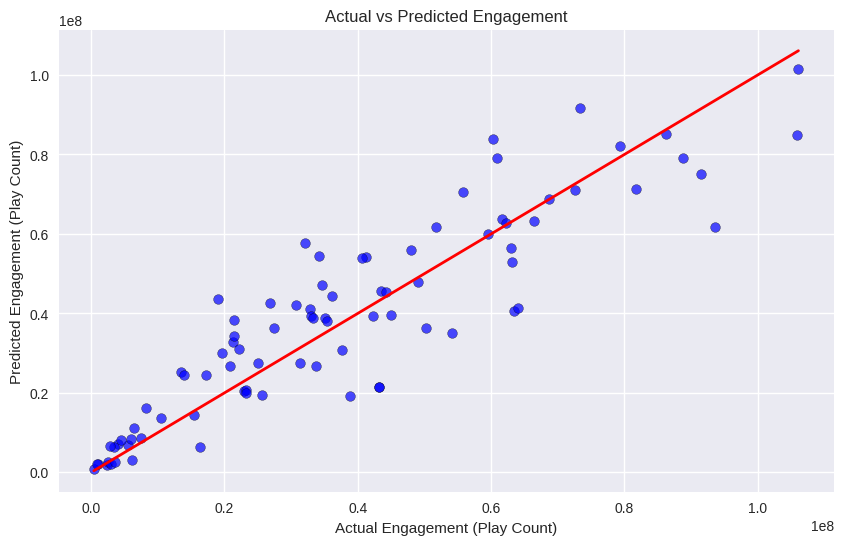

In [ ]:
# Plot actual vs nilai prediksi
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Diagonal line (ideal prediction)
plt.title('Actual vs Predicted Engagement')
plt.xlabel('Actual Engagement (Play Count)')
plt.ylabel('Predicted Engagement (Play Count)')
plt.grid(True)
plt.show()

# Analisis Sentimen

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import re

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to string to handle potential numeric data
    text = str(text)
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

tiktok['content'] = tiktok['text'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(tiktok['content'], y, test_size=0.2, random_state=42)

In [ ]:
# Vectorization
vectorizer = CountVectorizer()
X_train_count = vectorizer.fit_transform(X_train)
X_test_count = vectorizer.transform(X_test)

In [ ]:
# Train Model
model = MultinomialNB()
model.fit(X_train_count, y_train)

MultinomialNB()

In [ ]:
# Evaluate Model
y_pred = model.predict(X_test_count)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.19767441860465115
Classification Report:
              precision    recall  f1-score   support

      221000       0.00      0.00      0.00         1
      512600       0.00      0.00      0.00         1
      629400       0.00      0.00      0.00         1
      658000       0.00      0.00      0.00         1
     1200000       0.00      0.00      0.00         2
     1300000       0.00      0.00      0.00         1
     1400000       0.00      0.00      0.00         1
     2100000       0.00      0.00      0.00         1
     2500000       0.00      0.00      0.00         1
     3400000       0.00      0.00      0.00         1
     3600000       0.00      0.00      0.00         1
     3700000       0.00      0.00      0.00         0
     4000000       0.00      0.00      0.00         3
     5400000       0.00      0.00      0.00         1
     5900000       0.00      0.00      0.00         1
     6000000       0.00      0.00      0.00         1
     6200000       0.00     

In [ ]:
#  save dataset
tiktok.to_csv('tiktok.csv', index=False)